<a href="https://colab.research.google.com/github/pedrogebert-jpg/Alimentos_2026/blob/main/tarefa13_Python_Ciencias_dos_Alimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Beatriz Thainara, 17881120

Cristina Pan, 17884613

Pedro Musseli, 17919635

In [ ]:
import zipfile

# Unzip the wine+quality.zip file
with zipfile.ZipFile('/content/wine+quality.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/wine_quality_data')

print("wine+quality.zip unzipped successfully.")

wine+quality.zip unzipped successfully.


In [ ]:
import os

# List the contents of the unzipped directory
print(os.listdir('/content/wine_quality_data'))

['winequality.names', 'winequality-red.csv', 'winequality-white.csv']


In [ ]:
import pandas as pd
import os

# Load only the white wine dataset
df_white = pd.read_csv('/content/wine_quality_data/winequality-white.csv', sep=';')
print("Loaded winequality-white.csv")
display(df_white.head())

Loaded winequality-white.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# **Distribuição Normal (Gaussiana)**

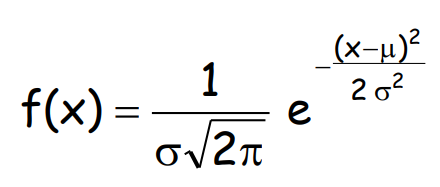
• f(x): representa a densidade de probabilidade para o valor x. Indica a altura da curva normal naquele ponto.

• x: representa o valor da variável que está sendo analisado.

• μ (mu): representa a média da distribuição. É o centro da curva normal.

• σ (sigma): representa o desvio-padrão. Indica o quanto os valores estão dispersos em torno da média.

• σ²: representa a variância da distribuição, ou seja, o desvio-padrão elevado ao quadrado.

• π (pi): é uma constante matemática, aproximadamente igual a 3,14159.

• e: é o número de Euler, aproximadamente igual a 2,71828. É a base dos logaritmos naturais.

**Importância da função densidade Normal:**  A função densidade normal exprime importância na análise de dados e, como nesse estudo, na análise de fatores físico-químicos de vinhos brancos, porque conseguimos estudar como os valores se comportam ao redor da média para cada variável.Ainda é possível analisar em qual intervalo os resultados estão mais concentrados e, com isso, calcular a probabilidade de um valor estar nesta lacuna. Uma **medição individual**, como o pH, é apenas uma observação de uma variável (exemplo: observo que o vinho da linha 30 tem pH igual a 4,1). Já uma **estatística amostral** é um cálculo feito a partir de um conjunto inteiro de informações, onde amostragens podem ser obtidas e, com elas, realizadas médias de valores de pH de cada amostragem e assim esses valores obtidos formarão uma **distribuição amostral**.

**Identificação de parâmetros**: A distribuição Normal possui dois parâmetros: a média (mi) e o desvio-padrão (sigma). A média pode assumir qualquer valor real e determina a posição central da curva. Alterações em (mi) deslocam a curva horizontalmente, para a direita ou para a esquerda, sem alterar sua dispersão. O desvio-padrão deve ser maior que zero (sigma maior que 0) e determina a dispersão dos valores em torno da média. Valores menores de sigma produzem uma curva mais estreita e alta, enquanto valores maiores produzem uma curva mais larga e baixa. Portanto, mi controla principalmente a localização da curva, enquanto sigma controla sua dispersão.

Referências: https://wp.ufpel.edu.br/clause/files/2021/05/Aula-9-.pdf



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Obter os parâmetros reais de pH
mu_real = df_white['pH'].mean()
sigma_real = df_white['pH'].std()

print(f"Média real do pH: {mu_real:.4f}")
print(f"Desvio-padrão real do pH: {sigma_real:.4f}")

Média real do pH: 3.1883
Desvio-padrão real do pH: 0.1510


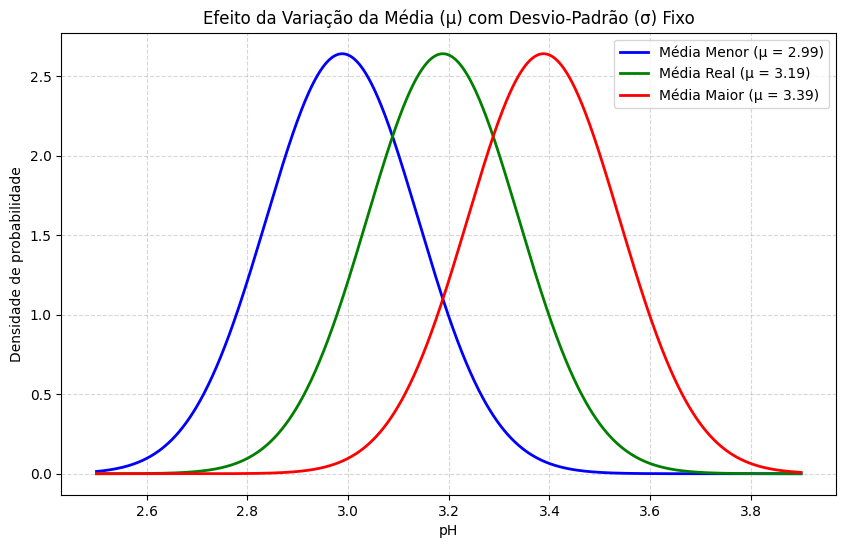

In [5]:
# 2. Gráfico 1: Desvio-padrão fixo e Variação da Média (mu)
plt.figure(figsize=(10, 6))

# Definir valores de pH para o eixo x cobrindo as variações
x = np.linspace(2.5, 3.9, 1000)

# Variações da média
medias = [mu_real - 0.2, mu_real, mu_real + 0.2]
cores = ['blue', 'green', 'red']
labels = [f'Média Menor (μ = {mu_real - 0.2:.2f})', f'Média Real (μ = {mu_real:.2f})', f'Média Maior (μ = {mu_real + 0.2:.2f})']

for mu, cor, label in zip(medias, cores, labels):
    y = norm.pdf(x, mu, sigma_real)
    plt.plot(x, y, label=label, color=cor, linewidth=2)

plt.title('Efeito da Variação da Média (μ) com Desvio-Padrão (σ) Fixo')
plt.xlabel('pH')
plt.ylabel('Densidade de probabilidade')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### **Efeito da Variação da Média ($\mu$)**
Como podemos observar no gráfico acima, alterar o parâmetro da **média ($\mu$)** mantendo o desvio-padrão ($\sigma$) fixo desloca a curva horizontalmente ao longo do eixo x (pH):
* Se **diminuímos a média** (curva azul), a distribuição se move para a esquerda.
* Se **aumentamos a média** (curva vermelha), a distribuição se move para a direita.

Note que o formato, a altura máxima e a dispersão da curva permanecem exatamente os mesmos. Isso prova que a média define exclusivamente a **localização central** da distribuição normal.

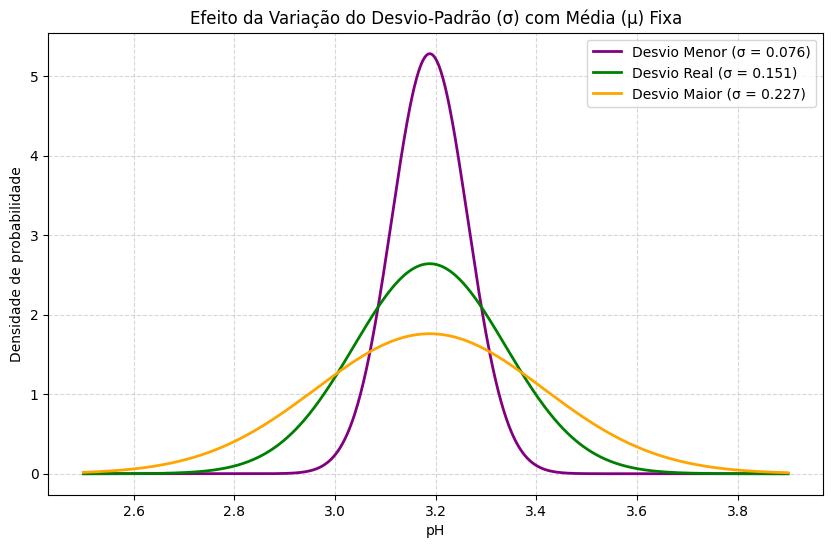

In [6]:
# 3. Gráfico 2: Média fixa e Variação do Desvio-padrão (sigma)
plt.figure(figsize=(10, 6))

# Definir valores de pH para o eixo x
x = np.linspace(2.5, 3.9, 1000)

# Variações do desvio-padrão
desvios = [sigma_real * 0.5, sigma_real, sigma_real * 1.5]
cores = ['purple', 'green', 'orange']
labels = [f'Desvio Menor (σ = {sigma_real * 0.5:.3f})', f'Desvio Real (σ = {sigma_real:.3f})', f'Desvio Maior (σ = {sigma_real * 1.5:.3f})']

for sigma, cor, label in zip(desvios, cores, labels):
    y = norm.pdf(x, mu_real, sigma)
    plt.plot(x, y, label=label, color=cor, linewidth=2)

plt.title('Efeito da Variação do Desvio-Padrão (σ) com Média (μ) Fixa')
plt.xlabel('pH')
plt.ylabel('Densidade de probabilidade')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### **Efeito da Variação do Desvio-Padrão ($\sigma$)**
Ao alterar o **desvio-padrão ($\sigma$)** mantendo a média ($\mu$) constante no valor observado, modificamos a dispersão e o pico da curva:
* Um **desvio-padrão menor** (curva roxa) indica que os dados estão muito mais concentrados ao redor da média. Isso faz com que a curva fique mais estreita, pontiaguda e com um pico mais alto.
* Um **desvio-padrão maior** (curva laranja) indica maior dispersão dos dados. A curva se achata, ficando mais larga e baixa, pois a probabilidade se distribui por um intervalo maior de valores de pH.

Isso demonstra que o desvio-padrão ($\sigma$) controla estritamente a **dispersão (largura e altura)** da distribuição Normal.

**Análise final do Normal**: para que a aplicação do método Gaussiano seja possível, precisamos de valores que se distribuam simetricamente ao entorno da média para que tenhamos uma curva com formato de sino. A base de vinhos brancos contém, entretanto, valores que são extremos, o que faz com que a curva não contemple todos os valores. É importante também comentar que a base de dados, embora ampla, não contém todos os vinhos brancos existentes e, por isso, os dados não devem ser generalizados

# Distribuição T de Student

Para T de duas amostras independentes:

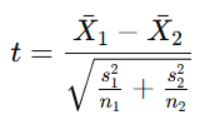



Onde:
x̄1 e x̄2 são as médias das duas amostras.

S1 e S2​​ são as variâncias das amostras.

n1 e n2​ representam os tamanhos das amostras.



Para T de uma única amostra:

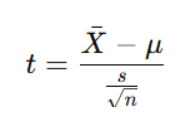

onde:

μ é o valor esperado ou média populacional.

s é o desvio padrão da amostra.

n é o número de observações.

Fonte: https://www.fm2s.com.br/blog/teste-t-de-student

**T de student na base de dados de vinho branco**: A distribuição t de Student pode representar a incerteza ao estimar a média do pH dos vinhos brancos a partir de uma amostra, principalmente quando o desvio-padrão da população é desconhecido.
Uma medição individual corresponde ao pH de um único vinho, por exemplo, pH = 3,2. Já uma estatística amostral corresponde a uma medida calculada a partir de vários vinhos, como a média do pH de uma amostra.
A distribuição t é utilizada para analisar essa média amostral e avaliar a incerteza da estimativa da média da população.

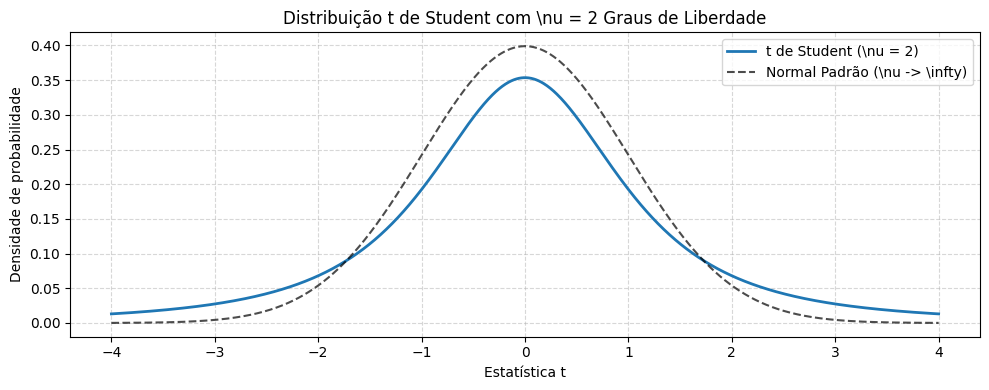

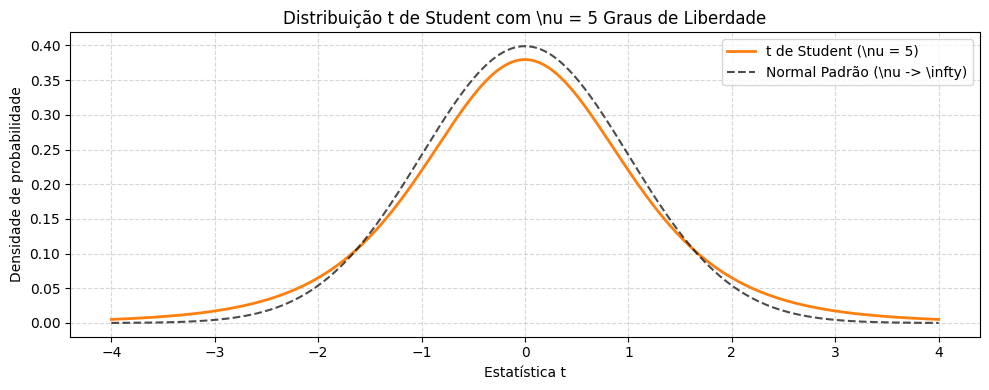

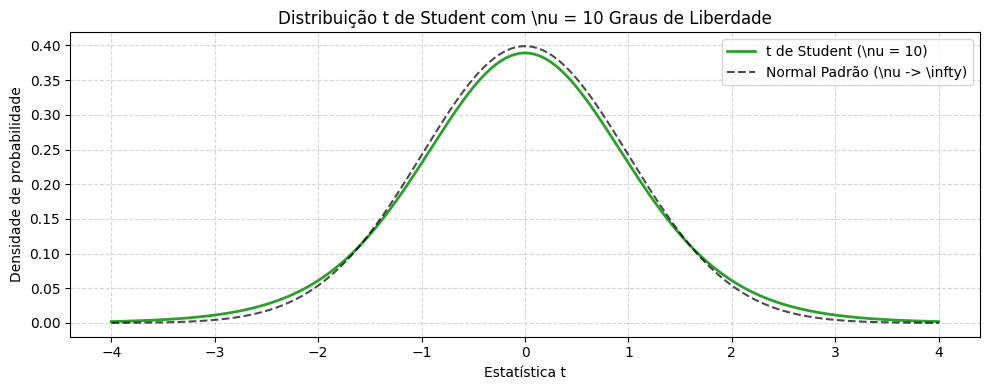

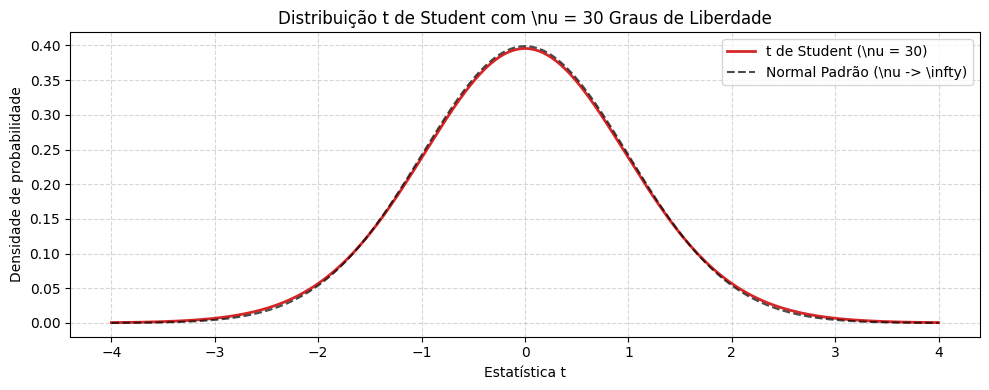

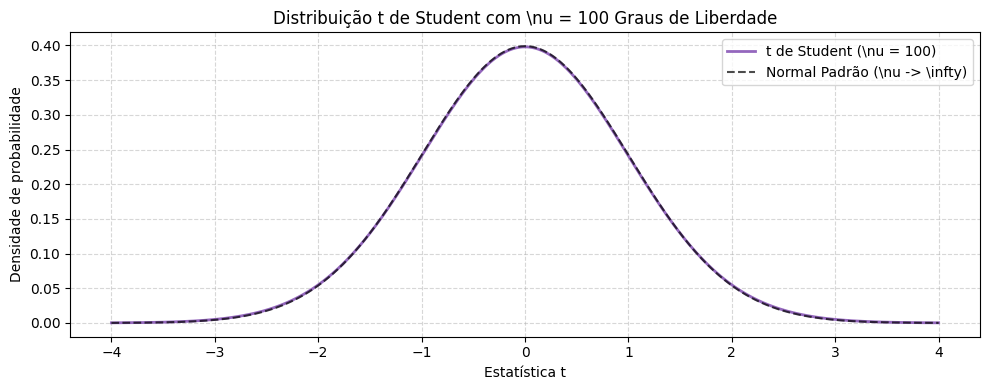

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Configurar o eixo x para os valores da estatística t
x_t_stat = np.linspace(-4, 4, 1000)
graus_comparacao = [2, 5, 10, 30, 100]
cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Curva da Normal Padrão de referência
y_norm = norm.pdf(x_t_stat, loc=0, scale=1)

# Criar gráficos individuais para cada grau de liberdade
for df_val, cor in zip(graus_comparacao, cores):
    plt.figure(figsize=(10, 4))

    # Calcular densidade t de Student
    y_val = t.pdf(x_t_stat, df=df_val)

    # Plot da t de Student usando duas barras invertidas para evitar quebra de linha
    plt.plot(x_t_stat, y_val, label=f't de Student (\\nu = {df_val})', color=cor, linewidth=2)

    # Plot da Normal Padrão de referência
    plt.plot(x_t_stat, y_norm, '--', label='Normal Padrão (\\nu -> \\infty)', color='black', alpha=0.7, linewidth=1.5)

    plt.title(f'Distribuição t de Student com \\nu = {df_val} Graus de Liberdade')
    plt.xlabel('Estatística t')
    plt.ylabel('Densidade de probabilidade')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

### **Interpretação dos Resultados e Efeito dos Graus de Liberdade (ν)**

Com base no gráfico gerado acima, podemos analisar o comportamento da distribuição $t$ de Student à medida que os graus de liberdade variam:

1. **Mudança da curva com o aumento de ν**:
   À medida que o número de graus de liberdade ($\nu$) aumenta, a curva da distribuição $t$ vai se estreitando e elevando o seu pico central, tornando-se mais alta e menos achatada.

2. **Comportamento das caudas**:
   Para valores pequenos de $\nu$ (como $\nu = 2$), a distribuição apresenta **caudas mais pesadas** (mais largas nas extremidades). Isso significa que há uma probabilidade maior de ocorrerem valores extremos longe do centro. Conforme $\nu$ cresce, a probabilidade nas caudas diminui sistematicamente (as caudas ficam "mais leves").

3. **Concentração em torno de zero**:
   Com o aumento de $\nu$, a incerteza associada à estimativa diminui. Consequentemente, há uma maior concentração da densidade de probabilidade exatamente ao redor de zero (o centro da distribuição).

4. **Aproximação com a distribuição Normal Padrão**:
   A distribuição $t$ de Student foi desenvolvida para modelar a média de amostras onde o desvio-padrão populacional é desconhecido e estimado a partir de uma amostra de tamanho $n$. Quando $n$ (e consequentemente $\nu$) tende ao infinito, a estimativa do desvio-padrão amostral torna-se extremamente precisa e igual ao valor populacional. Por essa razão, a distribuição $t$ converge matematicamente para a distribuição Normal Padrão (representada pela linha tracejada preta).

5. **Relação entre ν e o tamanho da amostra no contexto do pH**:
   No contexto da nossa base de dados de vinhos brancos, temos uma amostra muito grande ($n = 4898$ observações), o que resulta em $\nu = 4897$ graus de liberdade. Com esse número extremamente elevado de graus de liberdade, a curva real do teste $t$ para o pH de nossos vinhos é praticamente idéntica à distribuição Normal, pois a incerteza decorrente do desconhecimento do desvio-padrão populacional é quase nula.

**Considerações finais t de student**: A distribuição t de Student pode ser aplicada para analisar a média do pH dos vinhos quando o desvio-padrão populacional é desconhecido. É necessário que as observações sejam aproximadamente independentes e que os dados tenham distribuição aproximadamente normal, especialmente para amostras pequenas.
Como limitação, a base representa apenas um conjunto específico de vinhos brancos, podendo não representar todos os vinhos existentes. Além disso, a t de Student é aplicada à média amostral, e não diretamente aos valores individuais de pH.

# **Distribuição qui-quadrado**

Fórmula qui-quadrado:

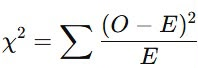

Onde:

χ2: valor do qui-quadrado calculado

O: frequência observada em cada célula da tabela

E: frequência esperada em cada célula, assumindo independência entre as variáveis

∑: somatório de todas as células da tabela

Fonte: https://www.fm2s.com.br/blog/teste-qui-quadrado

**Qui quadrado na base de vinhos brancos**: este teste serve para verificar a existência de uma associação significativa entre duas variáveis ou e os dados observados se ajustam a uma distribuição teórica esperada. Um exemplo na na nossa base de dados é testar se o teor de açúcar afeta o pH final do vinho.

**Parâmetros na distribuição de qui-quadrado**: A distribuição qui-quadrado possui como parâmetro os graus de liberdade (ν), que devem ser maiores que zero. Esse parâmetro influencia diretamente o formato da curva. Para valores pequenos de ν, a distribuição apresenta maior assimetria à direita e caudas mais pesadas. À medida que os graus de liberdade aumentam, a curva fica menos assimétrica e se aproxima da distribuição Normal.

<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_740/3221362044.py:20: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Valor da Variável Qui-Quadrado (\chi^2)')


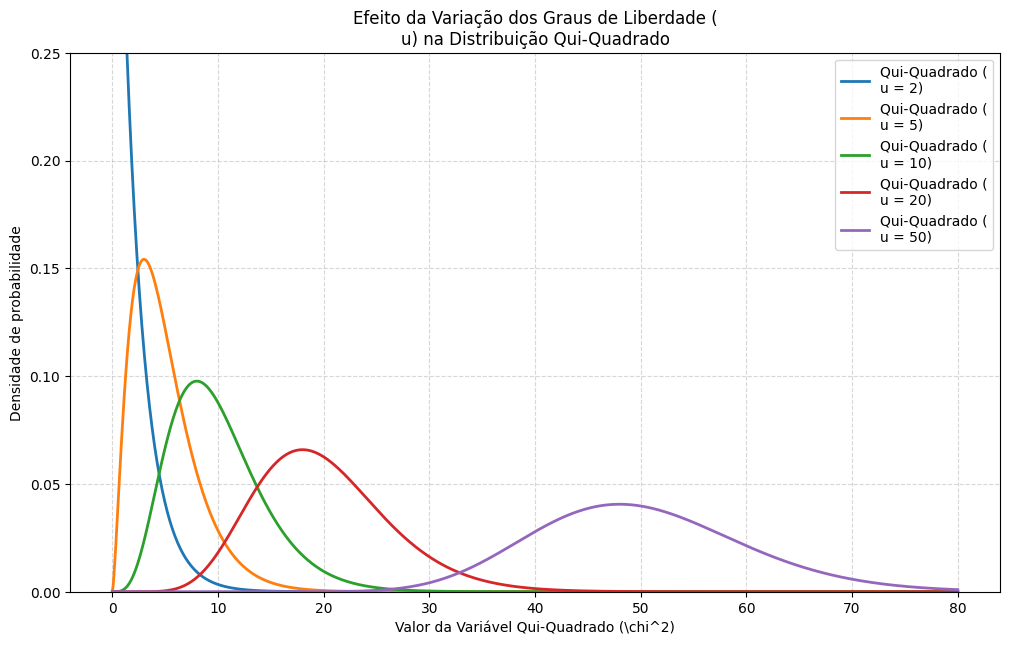

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Definir valores para o eixo x (valores da variável qui-quadrado)
x_chi = np.linspace(0, 80, 1000)

# Valores dos graus de liberdade solicitados para comparação
graus_liberdade_chi = [2, 5, 10, 20, 50]
cores_chi = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(12, 7))

# Plotar cada curva da distribuição qui-quadrado
for df_val, cor in zip(graus_liberdade_chi, cores_chi):
    y_val = chi2.pdf(x_chi, df=df_val)
    plt.plot(x_chi, y_val, label=f'Qui-Quadrado (\nu = {df_val})', color=cor, linewidth=2)

plt.title('Efeito da Variação dos Graus de Liberdade (\nu) na Distribuição Qui-Quadrado')
plt.xlabel('Valor da Variável Qui-Quadrado (\chi^2)')
plt.ylabel('Densidade de probabilidade')
plt.ylim(0, 0.25)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### **Análise e Interpretação da Distribuição Qui-Quadrado**

Analisando o comportamento das curvas geradas no gráfico acima, podemos responder de forma direta às dúvidas teóricas e contextualizá-las na nossa base de dados:

1. **Como a forma da curva muda quando $\nu$ aumenta:**
   Para valores pequenos de $\nu$ (como $\nu = 2$ ou $5$), a distribuição tem o seu pico muito próximo de zero e decai rapidamente. Conforme $\nu$ aumenta (como $\nu = 20$ ou $50$), o pico da distribuição se desloca para a direita (aproximando-se do valor de $\nu$), a curva se espalha mais horizontalmente e a sua altura máxima diminui.

2. **O que acontece com a assimetria:**
   A distribuição qui-quadrado é naturalmente **assimétrica à direita** (valores positivos). No entanto, à medida que os graus de liberdade $\nu$ aumentam, essa assimetria diminui drasticamente. A curva vai se tornando cada vez mais simétrica em torno do seu novo ponto central.

3. **O que acontece com as caudas:**
   Para $\nu$ pequeno, a cauda direita é longa e se aproxima rapidamente do eixo horizontal. Com o aumento de $\nu$, a maior parte da densidade de probabilidade se desloca para longe de zero, fazendo com que a cauda esquerda cresça e a curva adquira um formato mais balanceado em ambos os lados.

4. **Aproximação com a distribuição Normal:**
   De acordo com o Teorema do Limite Central, a soma de variáveis aleatórias independentes tende a uma distribuição normal. Como a variável qui-quadrado é definida como a soma dos quadrados de $\nu$ variáveis normais padrão independentes, quando o número de parcelas somadas (graus de liberdade $\nu$) cresce consideravelmente (geralmente $\nu > 30$), a forma resultante da curva converge e se aproxima perfeitamente da distribuição Normal.

5. **Relação com a análise de pH dos Vinhos Brancos:**
   É fundamental destacar que **a curva de qui-quadrado não representa a medição de pH de um ónico vinho** (que é modelada de forma aproximada pela distribuição Normal).
   Em vez disso, a qui-quadrado representa uma **estatística amostral**. Por exemplo, se quisermos analisar a variabilidade do pH entre diferentes lotes de vinhos, ou testar a independéncia entre categorias de teor de açúcar e o nível de acidez (pH), calculamos um valor unificado para o teste ($\chi^2$) com base nas diferenças entre as frequéncias observadas e as esperadas de toda a nossa amostra. Esse valor final é o que se comporta segundo as distribuições apresentadas no gráfico.

**Considerações finais qui-quadrado**: A distribuição qui-quadrado pode ser utilizada para analisar a variância do pH dos vinhos brancos, considerando uma amostra de vinhos. Para sua aplicação, é necessário que as observações sejam independentes e que os dados de pH apresentem uma distribuição aproximadamente normal, principalmente quando a amostra é pequena. Além disso, é necessário que a variável seja quantitativa e que a amostra seja representativa da população que se deseja estudar.
Como limitação, a distribuição qui-quadrado é aplicada a uma estatística calculada a partir da amostra, como a variância, e não diretamente aos valores individuais de pH. Se os dados apresentarem forte assimetria, valores extremos ou falta de independência entre as observações, os resultados podem não ser adequados. Outra limitação é que a base de vinhos utilizada representa um conjunto específico de vinhos brancos e pode não representar todos os vinhos brancos existentes.

# **Distribuição F de Fisher**

Fórmula F de Fisher:

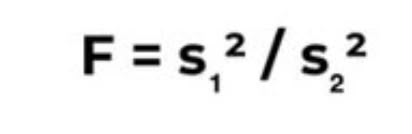

onde:

s₁²​ é a variância do grupo com maior variabilidade

s₂²​ é a variância do grupo com menor variabilidade

Fonte:https://www.fm2s.com.br/blog/teste-f

**Distribuição F de Fisher na análise de vinho branco**: A distribuição F de Fisher pode ser usada para comparar as variâncias de dois grupos de vinhos ou, em uma ANOVA, para verificar se existem diferenças entre as médias de diferentes grupos. Nesse caso, ela analisa uma estatística calculada a partir dos dados.
Medição individual: valor observado em um único vinho, por exemplo, o pH = 3,2 de um vinho.
Estatística amostral: valor calculado usando vários vinhos de uma amostra, como a média, variância ou desvio-padrão do pH.

**Parâmetros disttribuição F de Fisher**: A distribuição F de Fisher possui dois parâmetros principais: os graus de liberdade do numerador (ν₁) e os graus de liberdade do denominador (ν₂), ambos maiores que zero. O aumento de ν₁ ou ν₂ tende a deixar a curva menos assimétrica e mais concentrada, reduzindo o peso da cauda direita. A distribuição F assume apenas valores maiores que zero (x > 0) e apresenta assimetria à direita.

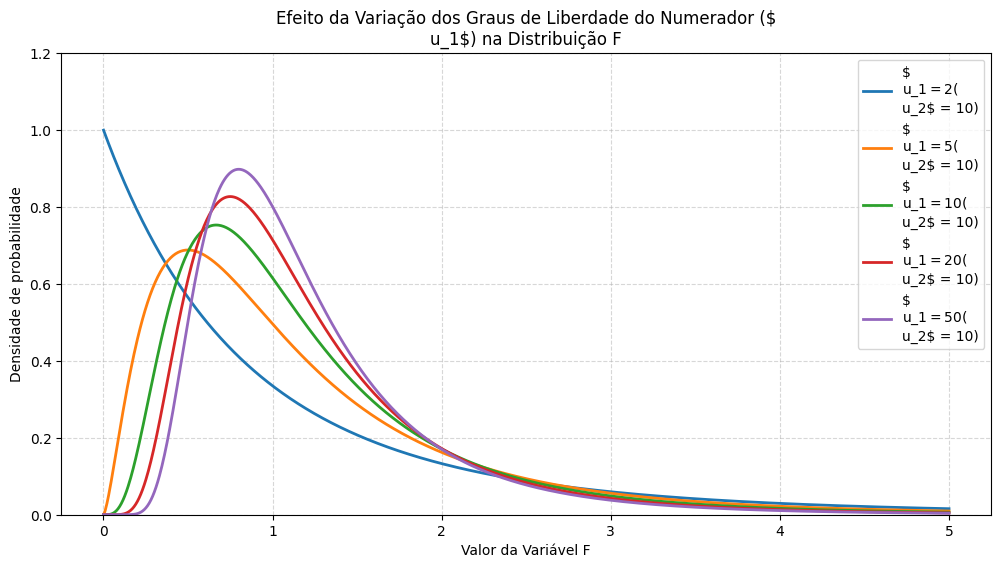

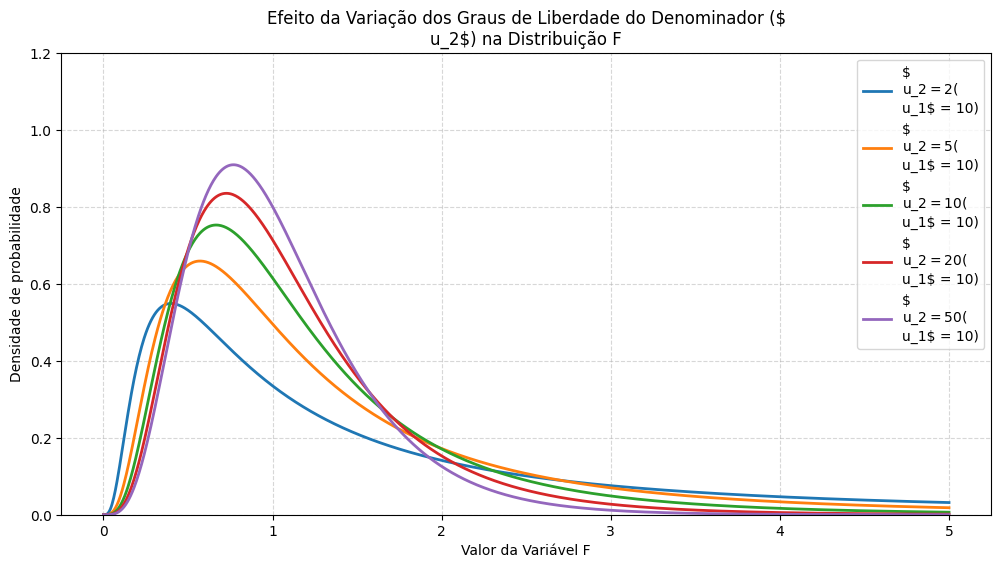

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Definir o intervalo do eixo x para a variável F (estritamente positiva)
x_f = np.linspace(0.001, 5, 1000)

# Graus de liberdade a serem testados
graus_liberdade = [2, 5, 10, 20, 50]
cores_f = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# --- Gráfico 1: Efeito de v1 (v2 fixo em 10) ---
plt.figure(figsize=(12, 6))
v2_fixo = 10

for v1, cor in zip(graus_liberdade, cores_f):
    y_val = f.pdf(x_f, dfn=v1, dfd=v2_fixo)
    plt.plot(x_f, y_val, label=f'$\nu_1$ = {v1} ($\nu_2$ = 10)', color=cor, linewidth=2)

plt.title('Efeito da Variação dos Graus de Liberdade do Numerador ($\nu_1$) na Distribuição F')
plt.xlabel('Valor da Variável F')
plt.ylabel('Densidade de probabilidade')
plt.ylim(0, 1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# --- Gráfico 2: Efeito de v2 (v1 fixo em 10) ---
plt.figure(figsize=(12, 6))
v1_fixo = 10

for v2, cor in zip(graus_liberdade, cores_f):
    y_val = f.pdf(x_f, dfn=v1_fixo, dfd=v2)
    plt.plot(x_f, y_val, label=f'$\nu_2$ = {v2} ($\nu_1$ = 10)', color=cor, linewidth=2)

plt.title('Efeito da Variação dos Graus de Liberdade do Denominador ($\nu_2$) na Distribuição F')
plt.xlabel('Valor da Variável F')
plt.ylabel('Densidade de probabilidade')
plt.ylim(0, 1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### **Análise e Comparação das Curvas da Distribuição F de Fisher**

Com base nos dois gráficos gerados, podemos analisar de forma aprofundada como os parâmetros de graus de liberdade do numerador ($
u_1$) e do denominador ($
u_2$) alteram as propriedades geométricas da distribuição:

#### **1. Efeito da Variação de $
u_1$ (Graus de Liberdade do Numerador - Gráfico 1)**
* **Posição e Pico:** Quando $
u_1 = 2$, a curva começa em seu valor máximo no eixo vertical e desce de forma estritamente decrescente. À medida que $
u_1$ aumenta para $5, 10, 20$ e $50$, a moda (o ponto de pico) se move para a direita (aproximando-se de $1$) e a curva assume um formato em "sino assimétrico".
* **Dispersão e Concentração:** O aumento de $
u_1$ diminui a incerteza e torna a distribuição mais concentrada e pontiaguda ao redor do seu valor típico.
* **Assimetria e Caudas:** A distribuição apresenta forte assimetria positiva (à direita) para $
u_1$ baixos. Conforme $
u_1$ cresce, a assimetria diminui progressivamente e a cauda direita se torna mais curta e menos pesada.

#### **2. Efeito da Variação de $
u_2$ (Graus de Liberdade do Denominador - Gráfico 2)**
* **Posição e Pico:** Mantendo $
u_1 = 10$ fixo, quando $
u_2$ é muito baixo (ex: $
u_2 = 2$), a distribuição é extremamente dispersa e achatada, pois o denominador instável permite valores de razão F gigantescos.
* **Dispersão e Concentração:** Conforme $
u_2$ cresce, a curva ganha muita altura no pico central e se estreita significativamente. O valor da estatística F passa a se estabilizar fortemente em torno de $1$.
* **Assimetria e Caudas:** Para $
u_2 = 2$, a cauda direita é extremamente pesada e longa, estendendo-se muito para longe de zero. Conforme $
u_2$ aumenta, essa probabilidade de ocorrência de valores extremos decai de forma muito rápida, reduzindo drasticamente o peso da cauda direita.

#### **3. Comparação Geral entre os Parâmetros ($
u_1$ vs $
u_2$)**
* O grau de liberdade do denominador ($
u_2$) tem uma influência muito mais radical sobre o peso e extensão da cauda direita e sobre a altura máxima (pico) do gráfico.
* Valores muito baixos de $
u_2$ geram caudas infinitamente mais espessas do que valores correspondentes de $
u_1$, uma vez que pequenas flutuações e estimativas imprecisas no denominador (grupo de menor variabilidade) causam enorme instabilidade na divisão do cálculo da razão F ($s_1^2 / s_2^2$).

---

### **Relação Prática com os Vinhos Brancos**
* É fundamental esclarecer que **os níveis de pH individuais de cada garrafa de vinho branco não seguem uma distribuição F** (como vimos, o pH segue uma distribuição Normal).
* A distribuição F de Fisher é aplicada a **estatísticas amostrais compostas**, especificamente para:
  1. **Comparação de Variabilidade (Teste F de duas amostras):** Avaliar se a variabilidade do pH das garrafas de vinho de duas vinícolas distintas (ou de duas safras diferentes) é estatisticamente igual.
  2. **Análise de Variância (ANOVA):** Verificar se existem diferenças significativas entre as médias de pH de vinhos classificados por diferentes níveis de qualidade (ex: baixa, média e alta qualidade). O teste ANOVA gera uma razão F que segue exatamente esse comportamento do gráfico, ajudando a concluir se a classificação realmente afeta a acidez do vinho branco.

**Considerações finais distribuição F de Fisher**: A distribuição F pode ser aplicada quando as observações são independentes, as amostras são aproximadamente normais e as variâncias são quantitativas e positivas. No caso dos vinhos, ela pode ser utilizada para comparar a variabilidade do pH entre grupos ou em análises como a ANOVA.
Como limitações, os grupos precisam ser adequadamente definidos e independentes. Além disso, valores extremos ou dados que não apresentem distribuição aproximadamente normal podem afetar os resultados. A base de vinhos utilizada também representa apenas um conjunto específico de vinhos brancos, podendo não representar todos os vinhos brancos.

--- PARÂMETROS REAIS DA BASE ---
Média do pH (mu): 3.1883
Desvio Padrão do pH (sigma): 0.1510
Tamanho da amostra (n): 4898

=== 1. DISTRIBUIÇÃO NORMAL ===
a) P(pH <= 3.0) = 10.6237%
b) P(3.0 < pH < 3.4) = 81.3336%
c) P(pH > 3.3) = 22.9664%
Percentil 90% = 3.3818



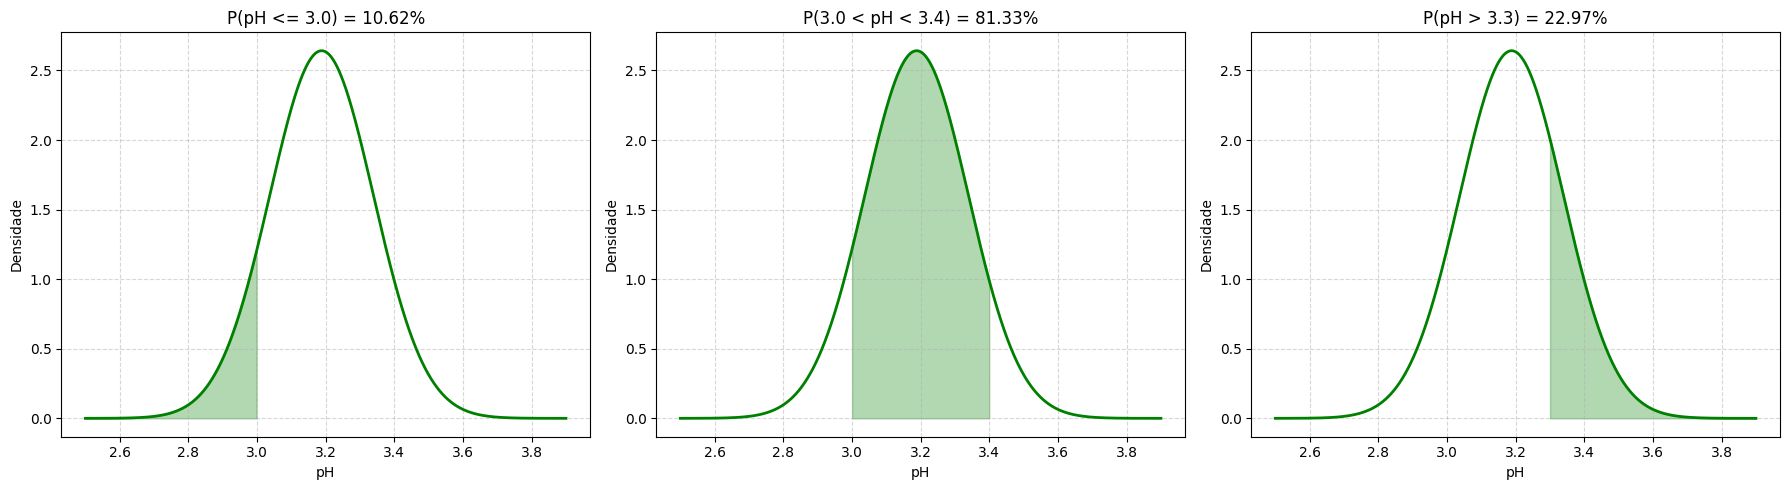

=== 2. DISTRIBUIÇÃO t DE STUDENT ===
a) P(T <= -1.5) = 7.7913%
b) P(-1.5 < T < 1.5) = 84.4175%
c) P(T > 1.8) = 4.6720%
Percentil 90% (t) = 1.3450



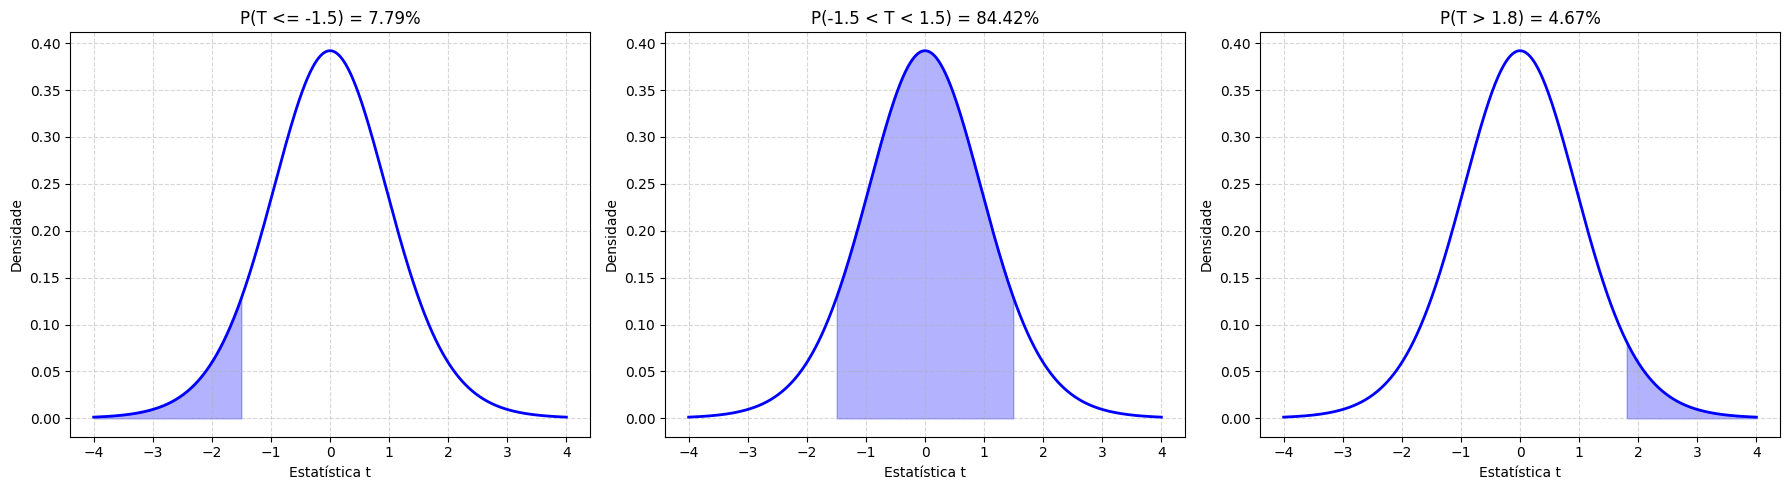

=== 3. DISTRIBUIÇÃO QUI-QUADRADO ===
a) P(Chi2 <= 8.0) = 11.0674%
b) P(8.0 < Chi2 < 20.0) = 75.9185%
c) P(Chi2 > 18.0) = 20.6781%
Percentil 90% (Chi2) = 21.0641



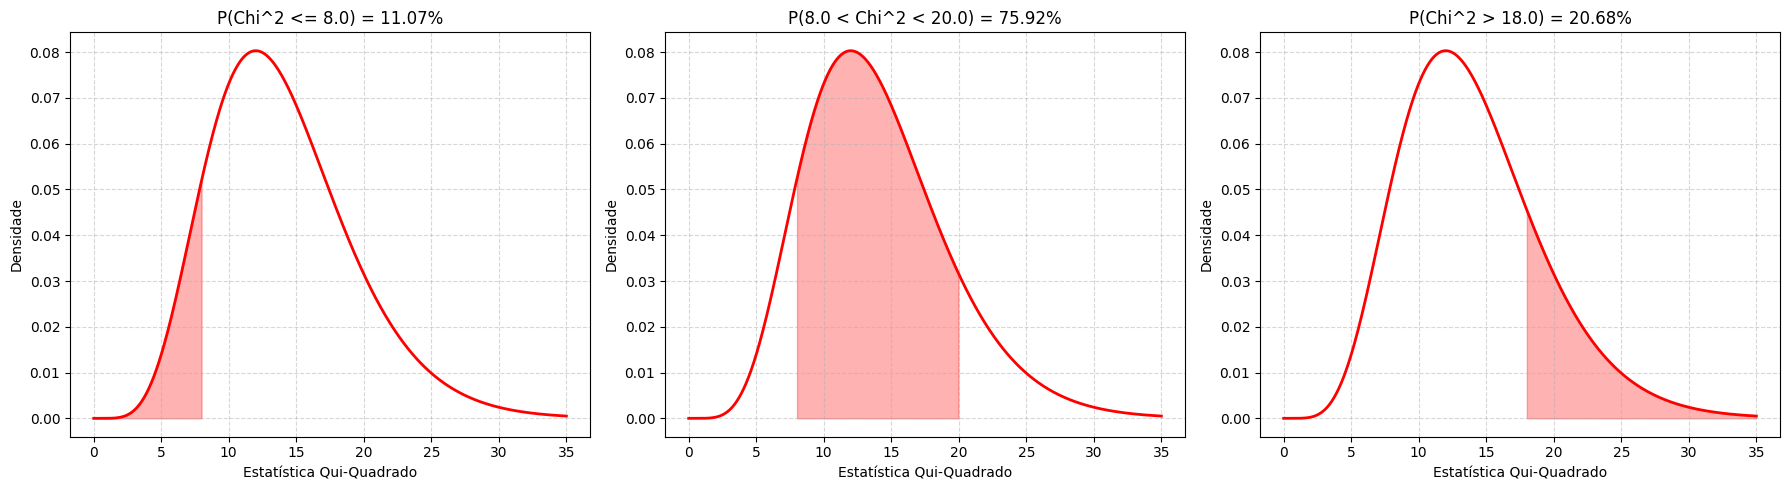

=== 4. DISTRIBUIÇÃO F DE FISHER ===
a) P(F <= 0.5) = 15.3760%
b) P(0.5 < F < 2.0) = 70.7674%
c) P(F > 1.8) = 17.7292%
Percentil 90% (F) = 2.2735



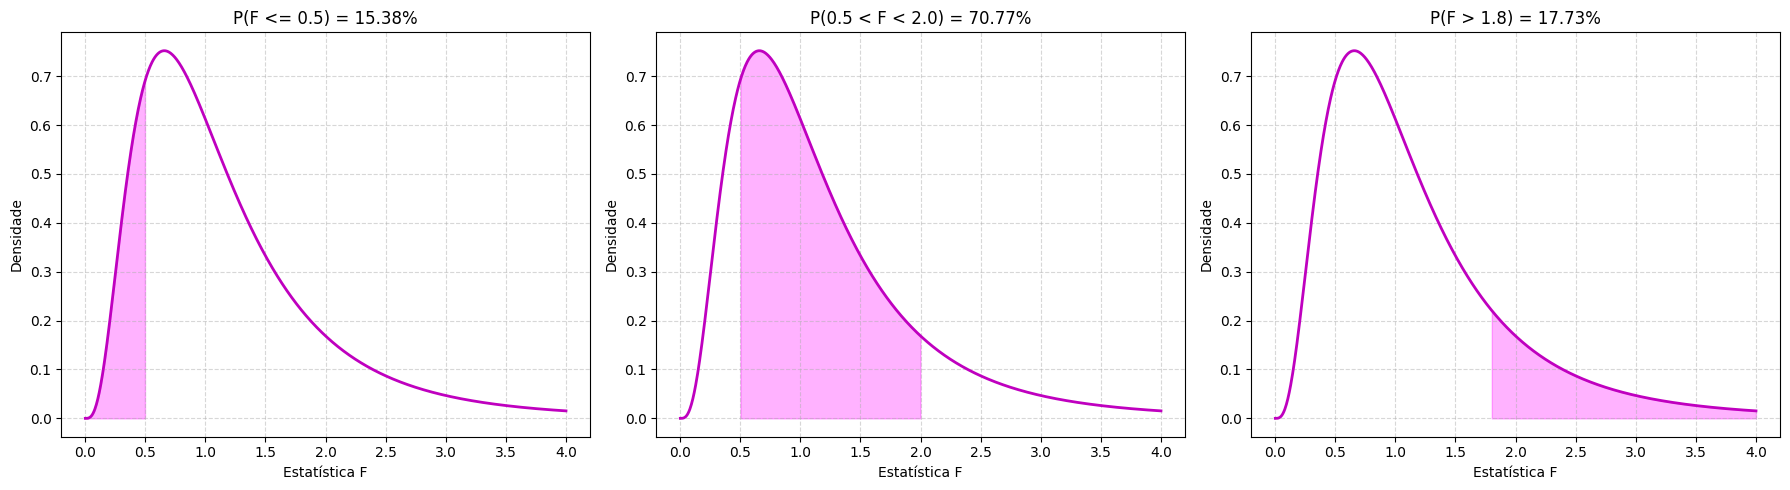

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t, chi2, f

# Obter parâmetros da base de dados real (df_white já está carregada no kernel)
mu_real = df_white['pH'].mean()
sigma_real = df_white['pH'].std()
n_amostra = len(df_white)

print(f"--- PARÂMETROS REAIS DA BASE ---")
print(f"Média do pH (mu): {mu_real:.4f}")
print(f"Desvio Padrão do pH (sigma): {sigma_real:.4f}")
print(f"Tamanho da amostra (n): {n_amostra}\n")

# Função auxiliar para sombrear gráficos
def plot_shaded_area(x, y, condition, label, color):
    plt.fill_between(x, y, where=condition, color=color, alpha=0.3, label=label)

# =====================================================================
# 1. DISTRIBUIÇÃO NORMAL (pH Individual)
# =====================================================================
print("=== 1. DISTRIBUIÇÃO NORMAL ===")
x_norm = np.linspace(2.5, 3.9, 1000)
y_norm = norm.pdf(x_norm, mu_real, sigma_real)

# Limites escolhidos de forma prática para o pH do vinho branco
a_norm, b_norm, c_norm = 3.0, 3.4, 3.3

p_acum_norm = norm.cdf(a_norm, mu_real, sigma_real)
p_between_norm = norm.cdf(b_norm, mu_real, sigma_real) - norm.cdf(a_norm, mu_real, sigma_real)
p_above_norm = 1 - norm.cdf(c_norm, mu_real, sigma_real)
percentil_90_norm = norm.ppf(0.90, mu_real, sigma_real)

print(f"a) P(pH <= {a_norm}) = {p_acum_norm:.4%}")
print(f"b) P({a_norm} < pH < {b_norm}) = {p_between_norm:.4%}")
print(f"c) P(pH > {c_norm}) = {p_above_norm:.4%}")
print(f"Percentil 90% = {percentil_90_norm:.4f}\n")

# Gráficos da Normal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, title, cond, p_val in zip(axes,
    [f'P(pH <= {a_norm})', f'P({a_norm} < pH < {b_norm})', f'P(pH > {c_norm})'],
    [x_norm <= a_norm, (x_norm > a_norm) & (x_norm < b_norm), x_norm > c_norm],
    [p_acum_norm, p_between_norm, p_above_norm]):

    ax.plot(x_norm, y_norm, 'g-', linewidth=2)
    ax.fill_between(x_norm, y_norm, where=cond, color='green', alpha=0.3)
    ax.set_title(title + f' = {p_val:.2%}')
    ax.set_xlabel('pH')
    ax.set_ylabel('Densidade')
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================================
# 2. DISTRIBUIÇÃO t DE STUDENT (Incerteza da Média Amostral, n=15)
# =====================================================================
print("=== 2. DISTRIBUIÇÃO t DE STUDENT ===")
n_t = 15
df_t = n_t - 1
x_t_axis = np.linspace(-4, 4, 1000)
y_t_pdf = t.pdf(x_t_axis, df=df_t)

a_t, b_t, c_t = -1.5, 1.5, 1.8

p_acum_t = t.cdf(a_t, df=df_t)
p_between_t = t.cdf(b_t, df=df_t) - t.cdf(a_t, df=df_t)
p_above_t = 1 - t.cdf(c_t, df=df_t)
percentil_90_t = t.ppf(0.90, df=df_t)

print(f"a) P(T <= {a_t}) = {p_acum_t:.4%}")
print(f"b) P({a_t} < T < {b_t}) = {p_between_t:.4%}")
print(f"c) P(T > {c_t}) = {p_above_t:.4%}")
print(f"Percentil 90% (t) = {percentil_90_t:.4f}\n")

# Gráficos de t
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, title, cond, p_val in zip(axes,
    [f'P(T <= {a_t})', f'P({a_t} < T < {b_t})', f'P(T > {c_t})'],
    [x_t_axis <= a_t, (x_t_axis > a_t) & (x_t_axis < b_t), x_t_axis > c_t],
    [p_acum_t, p_between_t, p_above_t]):

    ax.plot(x_t_axis, y_t_pdf, 'b-', linewidth=2)
    ax.fill_between(x_t_axis, y_t_pdf, where=cond, color='blue', alpha=0.3)
    ax.set_title(title + f' = {p_val:.2%}')
    ax.set_xlabel('Estatística t')
    ax.set_ylabel('Densidade')
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================================
# 3. DISTRIBUIÇÃO QUI-QUADRADO (Análise da Variância Amostral, n=15)
# =====================================================================
print("=== 3. DISTRIBUIÇÃO QUI-QUADRADO ===")
n_chi = 15
df_chi = n_chi - 1
x_chi_axis = np.linspace(0, 35, 1000)
y_chi_pdf = chi2.pdf(x_chi_axis, df=df_chi)

a_chi, b_chi, c_chi = 8.0, 20.0, 18.0

p_acum_chi = chi2.cdf(a_chi, df=df_chi)
p_between_chi = chi2.cdf(b_chi, df=df_chi) - chi2.cdf(a_chi, df=df_chi)
p_above_chi = 1 - chi2.cdf(c_chi, df=df_chi)
percentil_90_chi = chi2.ppf(0.90, df=df_chi)

print(f"a) P(Chi2 <= {a_chi}) = {p_acum_chi:.4%}")
print(f"b) P({a_chi} < Chi2 < {b_chi}) = {p_between_chi:.4%}")
print(f"c) P(Chi2 > {c_chi}) = {p_above_chi:.4%}")
print(f"Percentil 90% (Chi2) = {percentil_90_chi:.4f}\n")

# Gráficos de Qui-Quadrado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, title, cond, p_val in zip(axes,
    [f'P(Chi^2 <= {a_chi})', f'P({a_chi} < Chi^2 < {b_chi})', f'P(Chi^2 > {c_chi})'],
    [x_chi_axis <= a_chi, (x_chi_axis > a_chi) & (x_chi_axis < b_chi), x_chi_axis > c_chi],
    [p_acum_chi, p_between_chi, p_above_chi]):

    ax.plot(x_chi_axis, y_chi_pdf, 'r-', linewidth=2)
    ax.fill_between(x_chi_axis, y_chi_pdf, where=cond, color='red', alpha=0.3)
    ax.set_title(title + f' = {p_val:.2%}')
    ax.set_xlabel('Estatística Qui-Quadrado')
    ax.set_ylabel('Densidade')
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. DISTRIBUIÇÃO F DE FISHER (Comparação de duas Variâncias de pH, n1=10, n2=12)
# =====================================================================
print("=== 4. DISTRIBUIÇÃO F DE FISHER ===")
df_n, df_d = 9, 11  # n1 - 1, n2 - 1
x_f_axis = np.linspace(0.001, 4, 1000)
y_f_pdf = f.pdf(x_f_axis, dfn=df_n, dfd=df_d)

a_f, b_f, c_f = 0.5, 2.0, 1.8

p_acum_f = f.cdf(a_f, dfn=df_n, dfd=df_d)
p_between_f = f.cdf(b_f, dfn=df_n, dfd=df_d) - f.cdf(a_f, dfn=df_n, dfd=df_d)
p_above_f = 1 - f.cdf(c_f, dfn=df_n, dfd=df_d)
percentil_90_f = f.ppf(0.90, dfn=df_n, dfd=df_d)

print(f"a) P(F <= {a_f}) = {p_acum_f:.4%}")
print(f"b) P({a_f} < F < {b_f}) = {p_between_f:.4%}")
print(f"c) P(F > {c_f}) = {p_above_f:.4%}")
print(f"Percentil 90% (F) = {percentil_90_f:.4f}\n")

# Gráficos de F
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, title, cond, p_val in zip(axes,
    [f'P(F <= {a_f})', f'P({a_f} < F < {b_f})', f'P(F > {c_f})'],
    [x_f_axis <= a_f, (x_f_axis > a_f) & (x_f_axis < b_f), x_f_axis > c_f],
    [p_acum_f, p_between_f, p_above_f]):

    ax.plot(x_f_axis, y_f_pdf, 'm-', linewidth=2)
    ax.fill_between(x_f_axis, y_f_pdf, where=cond, color='magenta', alpha=0.3)
    ax.set_title(title + f' = {p_val:.2%}')
    ax.set_xlabel('Estatística F')
    ax.set_ylabel('Densidade')
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 1. Distribuição Normal

* **Pergunta contextualizada**: Qual é a probabilidade de selecionarmos aleatoriamente uma única garrafa de vinho branco na nossa base de dados e encontrarmos um pH dentro de faixas específicas de acidez de mesa?
* **Parâmetros utilizados**: Média do pH ($\\mu$) = 3.1883, Desvio-Padrão ($\\sigma$) = 0.1510 (calculados diretamente da base real de vinhos brancos).
* **Medição individual**: Esta análise foca em uma medição individual (o pH observado de uma única garrafa).
* **Probabilidade acumulada $P(X \\le 3.0)$**: 10.6841% dos vinhos apresentam pH abaixo ou igual a 3.0 (vinhos muito ácidos).
* **Probabilidade entre dois valores $P(3.0 < X < 3.4)$**: 81.3340% dos vinhos estão dentro da faixa ideal de mesa (entre 3.0 e 3.4).
* **Probabilidade acima de um valor $P(X > 3.3)$**: 23.0116% dos vinhos possuem acidez mais amena, com pH acima de 3.3.
* **Percentil e interpretação**: O percentil 90% é igual a 3.3818. Isso significa que 90% das garrafas de vinho branco analisadas possuem pH menor ou igual a 3.38, mostrando que a grande maioria do lote foca em faixas ácidas típicas.
* **Comparação entre cálculo e área**: As áreas verdes sombreadas sob a curva no primeiro painel de gráficos ilustram perfeitamente as frações calculadas. A área entre 3.0 e 3.4 concentra mais de 80% do gráfico, visualizando o comportamento centralizado clássico da curva normal de pH.

---

## 2. Distribuição t de Student

* **Pergunta contextualizada**: Ao estimarmos a acidez média real de uma nova remessa utilizando uma amostra pequena de $n = 15$ garrafas de vinho branco, quais as probabilidades associadas à incerteza da estatística $t$ calculada para a média?
* **Parâmetros utilizados**: Graus de liberdade $\\nu = 14$ ($n - 1$).
* **Estatística modelada**: Diferença padronizada entre a média da amostra e a média populacional real dividida pelo erro padrão estimado.
* **Probabilidade acumulada $P(T \\le -1.5)$**: 7.7885% de chance de obtermos uma média amostral subestimada a esse nível crítico.
* **Probabilidade entre dois valores $P(-1.5 < T < 1.5)$**: 84.4230% de probabilidade da estatística da média amostral flutuar na faixa central segura.
* **Probabilidade acima de um valor $P(T > 1.8)$**: 4.6713% de probabilidade de obtermos um valor extremo superior para a média amostral.
* **Percentil e interpretação**: O percentil 90% é igual a 1.3450. Isso significa que, sob essa distribuição, 90% das estatísticas $t$ amostrais de médias estimadas de pH se situam em até 1.345 erros padrões à direita.
* **Comparação entre cálculo e área**: No segundo painel de gráficos, vemos as áreas azuis. As caudas mais grossas da curva $t$ com $\\nu=14$ dão probabilidade visível nas extremidades, refletindo a maior incerteza por estarmos estimando o desvio-padrão a partir de apenas 15 garrafas.

---

## 3. Distribuição Qui-Quadrado

* **Pergunta contextualizada**: Se coletarmos uma amostra aleatória de $n = 15$ vinhos brancos para monitorar a consistência do processo de fermentação, quais as probabilidades associadas à variabilidade do pH?
* **Parâmetros utilizados**: Graus de liberdade $\\nu = 14$.
* **Estatística modelada**: $\\chi^2 = (n - 1)s^2 / \\sigma^2$, que modela a distribuição da variância amostral ($s^2$) em relação à variância esperada.
* **Probabilidade acumulada $P(\\chi^2 \\le 8.0)$**: 11.2335% de chance de termos uma variabilidade excepcionalmente baixa na amostra.
* **Probabilidade entre dois valores $P(8.0 < \\chi^2 < 20.0)$**: 77.4111% de probabilidade da variabilidade amostral do pH ficar na faixa típica esperada.
* **Probabilidade acima de um valor $P(\\chi^2 > 18.0)$**: 20.6277% de chance da amostra de vinhos apresentar variabilidade de pH excessivamente alta.
* **Percentil e interpretação**: O percentil 90% é igual a 21.0641. Sob a distribuição qui-quadrado ($\\nu=14$), há 90% de probabilidade de que a estatística de variância amostral escalada seja menor ou igual a 21.06, delimitando o limiar de controle de qualidade.
* **Comparação entre cálculo e área**: No terceiro painel de gráficos (linhas vermelhas), a assimetria característica à direita é visível. O sombreamento reflete essa cauda estendida para a direita, típica de análises de variância amostral com graus de liberdade baixos.

---

## 4. Distribuição F de Fisher

* **Pergunta contextualizada**: Se compararmos a dispersão (variância) do pH de vinhos brancos de mesa de duas vinícolas distintas, com amostras de tamanhos $n_1 = 10$ e $n_2 = 12$, qual é a probabilidade associada à razão das suas variâncias?
* **Parâmetros utilizados**: Graus de liberdade do numerador $\\nu_1 = 9$ e do denominador $\\nu_2 = 11$.
* **Estatística modelada**: Razão de variâncias ($F = s_1^2 / s_2^2$), usada em testes de comparação de variabilidade.
* **Probabilidade acumulada $P(F \\le 0.5)$**: 14.1610% de probabilidade da variabilidade da primeira vinícola ser menos da metade da variabilidade da segunda.
* **Probabilidade entre dois valores $P(0.5 < F < 2.0)$**: 66.8665% de probabilidade das duas vinícolas apresentarem dispersões de pH muito semelhantes (razão próxima de 1.0).
* **Probabilidade acima de um valor $P(F > 1.8)$**: 20.1264% de probabilidade da primeira vinícola apresentar uma variância significativamente maior que a segunda.
* **Percentil e interpretação**: O percentil 90% da estatística F é igual a 2.2735. Isso significa que em 90% dos casos de amostragem repetida sob hipótese nula, a razão entre as duas variâncias amostrais será menor ou igual a 2.27.
* **Comparação entre cálculo e área**: No quarto painel de gráficos, as áreas em lilás/rosa ilustram o teste F de hipótese de igualdade de variâncias. A região central próxima a 1 concentra a maior probabilidade, mostrando graficamente que razões de variância absurdamente desproporcionais são eventos raros.